In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import LabelEncoder #converts text into numbers

df=pd.read_csv('train.csv')
df=df.head(2000000)
print(df)

         Age  Grade  Gender         Race  SES_Quartile ParentalEducation  \
0         17     12  Female        White             3                HS   
1         18     12  Female        White             2                HS   
2         16     11  Female        White             2                HS   
3         14      9  Female        White             4        Bachelors+   
4         16     11  Female  Two-or-more             4       SomeCollege   
...      ...    ...     ...          ...           ...               ...   
1999995   17     12    Male        White             3        Bachelors+   
1999996   16     11    Male     Hispanic             2                HS   
1999997   15     10  Female        White             2                HS   
1999998   18     12    Male        White             1                HS   
1999999   16     11    Male        White             2                HS   

        SchoolType    Locale  TestScore_Math  TestScore_Reading  ...  \
0           Pub

In [2]:
print(df.shape)
print(df.isnull().sum())
print(df.isnull().values.any())

(2000000, 21)
Age                  0
Grade                0
Gender               0
Race                 0
SES_Quartile         0
ParentalEducation    0
SchoolType           0
Locale               0
TestScore_Math       0
TestScore_Reading    0
TestScore_Science    0
GPA                  0
AttendanceRate       0
StudyHours           0
InternetAccess       0
Extracurricular      0
PartTimeJob          0
ParentSupport        0
Romantic             0
FreeTime             0
GoOut                0
dtype: int64
False


In [3]:
#gpa prediction
features = [
    'TestScore_Math',
    'TestScore_Reading',
    'TestScore_Science',
    'AttendanceRate',
    'StudyHours',
    'InternetAccess',
    'Extracurricular',
    'PartTimeJob',
    'ParentSupport',
]

x=df[features].copy()

#normalizing the features with continous values so all are on same scale
continous_columns=[ 'TestScore_Math',
                   'TestScore_Reading',
                   'TestScore_Science',
                   'AttendanceRate',
                   'StudyHours']

for col in continous_columns:
    x[col]=(x[col]-x[col].mean(axis=0))/x[col].std(axis=0)
    #axis=0 means columns

#encoding the categorical features
categorical_columns=['InternetAccess',
                     'Extracurricular',
                     'PartTimeJob',
                     'ParentSupport']

for col in categorical_columns:
    x[col]=x[col].astype('category').cat.codes

x=x.values
y=df['GPA'].values.reshape(-1,1)

x=np.c_[np.ones((x.shape[0],1)),x] #added 1 columns of ones for bias which gets multiplied to theta0

rows=x.shape[0]
columns=x.shape[1]

#shuffling indices
ind=np.random.permutation(rows)

train_size=int(0.8*rows)
test_size=rows-train_size

train_index=ind[:train_size]
test_index=ind[train_size:]

x_train=x[train_index]
y_train=y[train_index]

x_test=x[test_index]
y_test=y[test_index]

print("Training Sample:\n",x_train.shape[0])
print("Testing Sample:\n",x_test.shape[0])

# Since the dataset is large-scale 80 % of 8 millions rows which is 6.4 M, batch gradient 
#descent would be expensive and slow also stochastic gradient descent would have much fluctuations due to large
#size of dataset.Therefore, we use mini-batch gradient descent which balances 
#convergence stability.

#how to choose epochs,hyperparameter,batch size ?
#we have 6.4M rows for training and 1.6M for testing therefore we use batch size of 512 as it 
#will provide 12,500 updates and in 100 epochs 1.25M updates which will help in fast convergence
#making batchsize would catch noise and model would be overfitted leading to strong assumptions
#rather than better generalizations and we use alpha = learning rate as 0.01 using 0.1 we fail
#to converge

def print_equation(theta):
        equation = "y = "
        for i in range(1,len(theta)):
            coef = theta[i,0]
            sign = "+" if coef >= 0 else "-"
            equation += f" {sign} {abs(coef):.4f}x{i+1}"
        equation += f" + {theta[0,0]:.4f}"
        print(equation)

m,n=x_train.shape
theta= np.zeros((n,1))

alpha= 0.01
epochs=100
batch_size=512

for epoch in range(epochs):
    index = np.random.permutation(m)
    x_train=x_train[index]
    y_train=y_train[index]

    for i in range(0,m,batch_size):
        x_batch=x_train[i:i+batch_size]
        y_batch=y_train[i:i+batch_size]

        prediction=np.dot(x_batch,theta)
        error= prediction-y_batch # predicted- actual

        d_theta=(1/len(x_batch))*np.dot(x_batch.T,error)
        theta=theta-alpha*d_theta

    if epoch % 10 == 0:
        train_pred=np.dot(x_train,theta)
        cost=(1/(2*(m)))*np.sum((train_pred-y_train)**2) #mean square error
        print(f"Epoch{epoch},Cost:{cost}")
        print_equation(theta)

test_pred=np.dot(x_test,theta)

Training Sample:
 1600000
Testing Sample:
 400000
Epoch0,Cost:0.04666946884211162
y =  + 0.1306x2 + 0.1291x3 + 0.1300x4 + 0.0050x5 + 0.0007x6 + 0.1834x7 + 0.0422x8 + 0.0321x9 + 0.0248x10 + 2.7866
Epoch10,Cost:0.04402350243977678
y =  + 0.1304x2 + 0.1315x3 + 0.1310x4 + 0.0018x5 - 0.0002x6 + 0.0014x7 - 0.0010x8 + 0.0007x9 + 0.0000x10 + 2.9978
Epoch20,Cost:0.04402380566798472
y =  + 0.1304x2 + 0.1305x3 + 0.1301x4 + 0.0016x5 - 0.0002x6 - 0.0005x7 - 0.0003x8 + 0.0005x9 - 0.0008x10 + 2.9953
Epoch30,Cost:0.0440216372057907
y =  + 0.1293x2 + 0.1309x3 + 0.1311x4 + 0.0012x5 + 0.0010x6 - 0.0003x7 + 0.0009x8 + 0.0011x9 - 0.0004x10 + 2.9956
Epoch40,Cost:0.044022701188692934
y =  + 0.1303x2 + 0.1302x3 + 0.1322x4 + 0.0021x5 - 0.0008x6 + 0.0002x7 - 0.0013x8 + 0.0009x9 + 0.0015x10 + 2.9963
Epoch50,Cost:0.04402644889838161
y =  + 0.1314x2 + 0.1307x3 + 0.1308x4 + 0.0029x5 + 0.0006x6 + 0.0017x7 + 0.0004x8 + 0.0006x9 - 0.0009x10 + 2.9973
Epoch60,Cost:0.04402304745385683
y =  + 0.1304x2 + 0.1295x3 + 0.1310x

In [5]:
gpa_level=[]

mae=np.mean(np.abs((test_pred-y_test)))
mse=np.mean((test_pred-y_test)**2)

print_equation(theta)
print("Mean absolute Error",mae)
print("Mean squared Error",mse)


gpa_level = []

for gpa in test_pred:
    value = gpa[0]   # because test_pred shape is (n,1)

    if value >= 3.5:
        gpa_level.append("High")
    elif value >= 2.5:
        gpa_level.append("Medium")
    else:
        gpa_level.append("Low")


df_test=df.iloc[test_index].copy()
df_test['Predicted_GPA']=test_pred.flatten()

df_test['GPA_level']=gpa_level
print(df_test[["Predicted_GPA", "GPA_level"]].head(1000))

y =  + 0.1306x2 + 0.1295x3 + 0.1315x4 + 0.0018x5 + 0.0004x6 + 0.0008x7 + 0.0009x8 + 0.0008x9 - 0.0007x10 + 2.9968
Mean absolute Error 0.23677298334110997
Mean squared Error 0.08767387599745148
         Predicted_GPA GPA_level
52316         2.975579    Medium
1255485       2.818070    Medium
279906        3.486523    Medium
1370519       3.679732      High
1137438       2.616900    Medium
...                ...       ...
320094        2.989531    Medium
738529        3.215516    Medium
1191643       3.353180    Medium
1917004       3.987399      High
1865942       2.493137       Low

[1000 rows x 2 columns]


In [6]:
###### print("\nEnter Student Details for GPA Prediction:")

math_score = float(input("Enter Math Test Score: "))
reading_score = float(input("Enter Reading Test Score: "))
science_score = float(input("Enter science Test Score: "))
attendance = float(input("Enter Attendance Rate (0 to 1): "))
study_hours = float(input("Enter Study Hours: "))
internet = int(input("Internet Access? (1 = Yes, 0 = No): "))
extra = int(input("Extracurricular? (1 = Yes, 0 = No): "))
parttime = int(input("Part Time Job? (1 = Yes, 0 = No): "))
parentsupport = int(input("Parent Support? (1 = Yes, 0 = No): "))

# Normalize
math_score = (math_score - df['TestScore_Math'].mean()) / df['TestScore_Math'].std()
reading_score = (reading_score - df['TestScore_Reading'].mean()) / df['TestScore_Reading'].std()
science_score = (science_score - df['TestScore_Science'].mean()) / df['TestScore_Science'].std()
attendance = (attendance - df['AttendanceRate'].mean()) / df['AttendanceRate'].std()
study_hours = (study_hours - df['StudyHours'].mean()) / df['StudyHours'].std()

# Create input array
user_input = np.array([
    1,  # bias term
    math_score,
    reading_score,
    science_score,
    attendance,
    study_hours,
    internet,
    extra,
    parttime,
    parentsupport
]).reshape(1, -1)


predicted_gpa = np.dot(user_input, theta)
value=predicted_gpa
level=""
if value >= 3.5:
    level="High"
elif value >= 2.5:
    level="Medium"
else:
    level="Low"
print("\nPredicted GPA:",predicted_gpa)
print("\nGPA level is:",level)

Enter Math Test Score:  99
Enter Reading Test Score:  25
Enter science Test Score:  56
Enter Attendance Rate (0 to 1):  0.6
Enter Study Hours:  0.8
Internet Access? (1 = Yes, 0 = No):  1
Extracurricular? (1 = Yes, 0 = No):  0
Part Time Job? (1 = Yes, 0 = No):  0
Parent Support? (1 = Yes, 0 = No):  0



Predicted GPA: [[2.39997715]]

GPA level is: Low


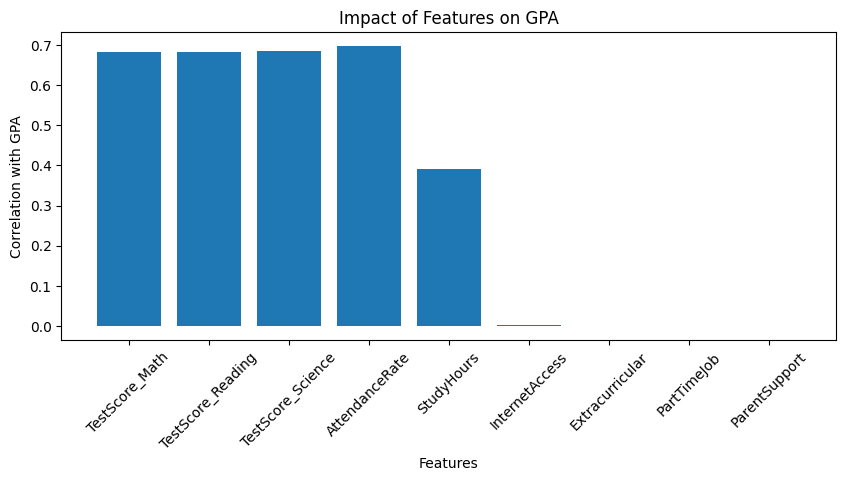

In [7]:
feature = [
    'TestScore_Math',
    'TestScore_Reading',
    'TestScore_Science',
    'AttendanceRate',
    'StudyHours',
    'InternetAccess',
    'Extracurricular',
    'PartTimeJob',
    'ParentSupport',
]

values = [
    df['TestScore_Math'].corr(df['GPA']),
    df['TestScore_Science'].corr(df['GPA']),
    df['TestScore_Reading'].corr(df['GPA']),
    df['AttendanceRate'].corr(df['GPA']),
    df['StudyHours'].corr(df['GPA']),
    df['InternetAccess'].corr(df['GPA']),
    df['PartTimeJob'].corr(df['GPA']),
    df['Extracurricular'].corr(df['GPA']),
    df['ParentSupport'].corr(df['GPA']),
]

plt.figure(figsize=(10,4))

plt.bar(feature, values)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Correlation with GPA")
plt.title("Impact of Features on GPA")

plt.show()


In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import LabelEncoder #converts text into numbers



df=pd.read_csv('train.csv')
df=df.head(100000)
print(df)
df1=df.copy()
df1=df1.sample(frac=1,random_state=42).reset_index(drop=True)

features = [
    'TestScore_Math',
    'TestScore_Reading',
    'TestScore_Science',
    'AttendanceRate',
    'StudyHours',
    'InternetAccess',
    'Extracurricular',
    'PartTimeJob',
    'ParentSupport',
]

continous_columns=[ 'TestScore_Math',
                   'TestScore_Reading',
                   'TestScore_Science',
                   'AttendanceRate',
                   'StudyHours']

#encoding the categorical features
categorical_columns=['InternetAccess',
                     'Extracurricular',
                     'PartTimeJob',
                     'ParentSupport']

x_all = df1[features].copy()

# normalize continuous columns
for col in continous_columns:
    x_all[col] = (x_all[col] - df1[col].mean()) / df1[col].std()

# encode categorical
for col in categorical_columns:
    x_all[col] = x_all[col].astype('category').cat.codes

x_all = x_all.values
x_all = np.c_[np.ones((x_all.shape[0],1)), x_all]

predicted_all = np.dot(x_all, theta)

df1['Predicted_GPA'] = predicted_all.flatten()

risk_label=[]

for i in range(len(df1)):
    gpa=df1.loc[i,'Predicted_GPA']
    attend=df1.loc[i,'AttendanceRate']
    study=df1.loc[i,'StudyHours']
    freetime=df1.loc[i,'FreeTime']
    goout=df1.loc[i,'GoOut']

    score=0;

    if gpa < 2.5: score += 2
    if attend < 0.75: score += 2
    if study < 2: score += 1
    if freetime > 3: score += 1
    if goout > 3: score += 2

    if score >= 5:
        risk = "High"
    elif score >= 3:
        risk = "Medium"
    else:
        risk = "Low"

    # small noise
    if np.random.rand() < 0.03:
        risk = np.random.choice(["High","Medium","Low"])
    risk_label.append(risk)    

df1['RiskLevel']=risk_label

knn_features = [
    'AttendanceRate',
    'StudyHours',
    'FreeTime',
    'GoOut'
]

x1 = df1[knn_features].values
means = x1.mean(axis=0)
stds = x1.std(axis=0)
x1 = (x1 - means) / stds
y1 = df1["RiskLevel"].values

rows = len(x1)

#indices = np.random.permutation(rows)

train_size = int(0.8 * rows)

#train_idx = indices[:train_size]
#test_idx = indices[train_size:]

x_train_knn = x1[:train_size]
y_train_knn = y1[:train_size]

x_test_knn = x1[train_size:train_size+1000]
y_test_knn = y1[train_size:train_size+1000]

correct=0
k_test=7
test_pred=[]
for j in range(len(x_test_knn)):
    distances = np.sqrt(np.sum((x_train_knn - x_test_knn[j])**2 , axis=1))

    k_idx = np.argsort(distances)[:k_test]

    k_labels = y_train_knn[k_idx]

    pred = max(set(k_labels), key=list(k_labels).count)

    test_pred.append(pred)

    if pred == y_test_knn[j]:
        correct += 1
        
accuracy = correct/(len(x_test_knn))

print("\nKNN accuracy:",accuracy)
print("\nfirst 10 test predictions vs actual labels")

for i in range(10):
    print("Predicted:",test_pred[i],"|Actual:",y_test_knn[i])
    
print("\n enter details for Risk Prediction")

study=float(input("study hours:"))
freetime=float(input("Free Time (1-5):"))
goout=float(input("Go Out time : "))
attendance=float(input("Attendance Rate (0-1):"))
#gpa=float(input("Predicted GPA: "))
k=int(input("enter value of K (nearest neigbors):"))

#gpa = (gpa - df1['Predicted_GPA'].mean()) / df1['Predicted_GPA'].std()
#attendance = (attendance - df1['AttendanceRate'].mean()) / df1['AttendanceRate'].std()
#study = (study - df1['StudyHours'].mean()) / df1['StudyHours'].std()

user_point=np.array([attendance,study,freetime,goout])
user_point=(user_point - means)/stds

distances = np.sqrt(np.sum((x_train_knn - user_point)**2 , axis=1))

k_idx = np.argsort(distances)[:k]

k_labels = y_train_knn[k_idx]

prediction = max(set(k_labels), key=list(k_labels).count)

print("\nUser Predicted Risk Level:", prediction)

       Age  Grade  Gender         Race  SES_Quartile ParentalEducation  \
0       17     12  Female        White             3                HS   
1       18     12  Female        White             2                HS   
2       16     11  Female        White             2                HS   
3       14      9  Female        White             4        Bachelors+   
4       16     11  Female  Two-or-more             4       SomeCollege   
...    ...    ...     ...          ...           ...               ...   
99995   15     10  Female        Black             3               <HS   
99996   17     12  Female     Hispanic             4                HS   
99997   15     10    Male        White             2       SomeCollege   
99998   17     12    Male        White             3       SomeCollege   
99999   16     11    Male        White             4                HS   

      SchoolType    Locale  TestScore_Math  TestScore_Reading  ...       GPA  \
0         Public  Suburban     

study hours: 2
Free Time (1-5): 1
Go Out time :  1
Attendance Rate (0-1): 0.6
enter value of K (nearest neigbors): 3



User Predicted Risk Level: Medium


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


accuracy = accuracy_score(y_test_knn[:len(test_pred)], test_pred)
print("\nKNN Accuracy:", accuracy)


cm = confusion_matrix(y_test_knn[:len(test_pred)], test_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_knn[:len(test_pred)], test_pred,zero_division=0))


KNN Accuracy: 0.922

Confusion Matrix:
[[  1   8   4]
 [  0 825  17]
 [  3  46  96]]

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.08      0.12        13
         Low       0.94      0.98      0.96       842
      Medium       0.82      0.66      0.73       145

    accuracy                           0.92      1000
   macro avg       0.67      0.57      0.60      1000
weighted avg       0.91      0.92      0.92      1000



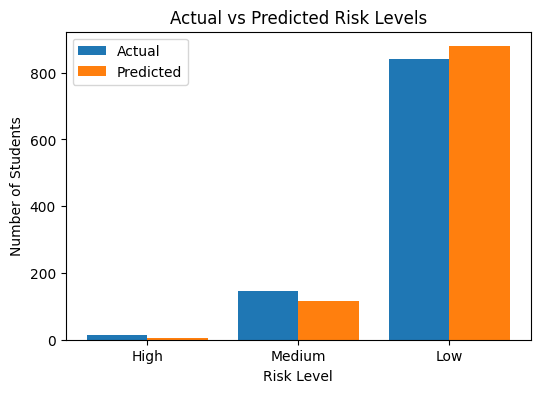

In [12]:
import matplotlib.pyplot as plt
import numpy as np

actual = y_test_knn[:len(test_pred)]
predicted = np.array(test_pred)

classes = ["High","Medium","Low"]

actual_counts = []
pred_counts = []

for c in classes:
    actual_counts.append(np.sum(actual == c))
    pred_counts.append(np.sum(predicted == c))

x = np.arange(len(classes))

plt.figure(figsize=(6,4))

plt.bar(x-0.2, actual_counts, width=0.4, label="Actual")
plt.bar(x+0.2, pred_counts, width=0.4, label="Predicted")

plt.xticks(x, classes)

plt.xlabel("Risk Level")
plt.ylabel("Number of Students")
plt.title("Actual vs Predicted Risk Levels")

plt.legend()

plt.show()

#this helps to show performance of model when no. of actual and predicted labels is almost same for all class. 